# Phần 2 — Trực quan hoá & Phân tích EDA

## Business problem

> **Doanh nghiệp thời trang thương mại điện tử không chỉ cần tăng doanh thu, mà cần tăng trưởng có kiểm soát: đúng mùa vụ, đúng danh mục, đúng kênh, hạn chế trả hàng và tránh mất doanh thu do stockout.**

**EDA nên trả lời 4 câu hỏi:**

1. Doanh thu tăng/giảm như thế nào?

2. Yếu tố nào kéo doanh thu và biên lợi nhuận?

3. Rủi ro nào đang làm mất doanh thu?

4. Doanh nghiệp nên làm gì tiếp theo?

### 1. Import

In [15]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = Path("dataset")
if not (DATA_DIR / "sales.csv").exists():
    DATA_DIR = Path(".")

# Theme thống nhất: nền sáng, trục gọn, palette dễ đọc
sns.set_theme(style="ticks", context="notebook", font_scale=1.05)
sns.set_palette(sns.color_palette("viridis", n_colors=8))
plt.rcParams.update(
    {
        "figure.figsize": (12, 6),
        "figure.facecolor": "#f8f9fa",
        "axes.facecolor": "#f8f9fa",
        "axes.edgecolor": "#adb5bd",
        "axes.linewidth": 1.0,
        "axes.titlepad": 14,
        "axes.labelpad": 10,
        "axes.titlesize": 14,
        "axes.titleweight": "600",
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.title_fontsize": 10,
        "legend.fontsize": 10,
        "legend.frameon": True,
        "legend.framealpha": 0.92,
        "legend.edgecolor": "#dee2e6",
        "grid.alpha": 0.45,
        "grid.color": "#dee2e6",
        "grid.linestyle": "--",
        "font.family": "sans-serif",
        "axes.grid": True,
        "axes.axisbelow": True,
    }
)

# Màu cố định cho đường biểu diễn / trục kép (dễ phân biệt)
LINE_DAILY, LINE_MA30, LINE_MA90 = "#748ffc", "#2b8a3e", "#e67700"
TWIN_FILL, TWIN_ACCENT = "#339af0", "#c92a2a"

pd.options.display.float_format = "{:,.2f}".format

### 2. Load dữ liệu và tạo bảng phân tích

In [16]:
sales = pd.read_csv(DATA_DIR / "sales.csv", parse_dates=["Date"])
orders = pd.read_csv(DATA_DIR / "orders.csv", parse_dates=["order_date"])
order_items = pd.read_csv(DATA_DIR / "order_items.csv", low_memory=False)
products = pd.read_csv(DATA_DIR / "products.csv")
customers = pd.read_csv(DATA_DIR / "customers.csv", parse_dates=["signup_date"])
geography = pd.read_csv(DATA_DIR / "geography.csv")
payments = pd.read_csv(DATA_DIR / "payments.csv")
shipments = pd.read_csv(DATA_DIR / "shipments.csv", parse_dates=["ship_date", "delivery_date"])
returns = pd.read_csv(DATA_DIR / "returns.csv", parse_dates=["return_date"])
reviews = pd.read_csv(DATA_DIR / "reviews.csv", parse_dates=["review_date"])
inventory = pd.read_csv(DATA_DIR / "inventory.csv", parse_dates=["snapshot_date"])
web_traffic = pd.read_csv(DATA_DIR / "web_traffic.csv", parse_dates=["date"])
promotions = pd.read_csv(DATA_DIR / "promotions.csv", parse_dates=["start_date", "end_date"])

data_overview = pd.DataFrame({
    "table": ["sales", "orders", "order_items", "products", "customers", "geography", "payments", "shipments", "returns", "reviews", "inventory", "web_traffic", "promotions"],
    "rows": [len(sales), len(orders), len(order_items), len(products), len(customers), len(geography), len(payments), len(shipments), len(returns), len(reviews), len(inventory), len(web_traffic), len(promotions)],
    "columns": [sales.shape[1], orders.shape[1], order_items.shape[1], products.shape[1], customers.shape[1], geography.shape[1], payments.shape[1], shipments.shape[1], returns.shape[1], reviews.shape[1], inventory.shape[1], web_traffic.shape[1], promotions.shape[1]]
})
display(data_overview)

,table,rows,columns
0,sales,3833,3
1,orders,646945,8
2,order_items,714669,7
3,products,2412,8
4,customers,121930,7
5,geography,39948,4
6,payments,646945,4
7,shipments,566067,4
8,returns,39939,7
9,reviews,113551,7


In [17]:
# Sales-level features
sales = sales.sort_values("Date").copy()
sales["gross_margin"] = sales["Revenue"] - sales["COGS"]
sales["gross_margin_pct"] = sales["gross_margin"] / sales["Revenue"]
sales["year"] = sales["Date"].dt.year
sales["month"] = sales["Date"].dt.month
sales["month_name"] = sales["Date"].dt.month_name()
sales["dow"] = sales["Date"].dt.day_name()
sales["week"] = sales["Date"].dt.isocalendar().week.astype(int)
sales["ym"] = sales["Date"].dt.to_period("M").dt.to_timestamp()
sales["rev_30d_ma"] = sales["Revenue"].rolling(30, min_periods=7).mean()
sales["rev_90d_ma"] = sales["Revenue"].rolling(90, min_periods=30).mean()

# Transaction-level table
items_prod = order_items.merge(products, on="product_id", how="left")
transactions = items_prod.merge(
    orders[["order_id", "order_date", "order_status", "customer_id", "zip", "payment_method", "device_type", "order_source"]],
    on="order_id",
    how="left"
)
transactions = transactions.merge(geography[["zip", "region", "city"]], on="zip", how="left")
transactions["gross_sales"] = transactions["quantity"] * transactions["unit_price"]
transactions["net_sales"] = transactions["gross_sales"] - transactions["discount_amount"]
transactions["estimated_cogs"] = transactions["quantity"] * transactions["cogs"]
transactions["gross_profit"] = transactions["net_sales"] - transactions["estimated_cogs"]
transactions["gross_margin_pct"] = transactions["gross_profit"] / transactions["net_sales"].replace(0, np.nan)
transactions["has_promo"] = transactions["promo_id"].notna() | transactions["promo_id_2"].notna()
transactions["order_month"] = transactions["order_date"].dt.to_period("M").dt.to_timestamp()
transactions["order_year"] = transactions["order_date"].dt.year

# Operational tables
shipments["delivery_days"] = (shipments["delivery_date"] - shipments["ship_date"]).dt.days

traffic_daily = web_traffic.groupby("date", as_index=False).agg(
    sessions=("sessions", "sum"),
    unique_visitors=("unique_visitors", "sum"),
    page_views=("page_views", "sum"),
    bounce_rate=("bounce_rate", "mean"),
    avg_session_duration_sec=("avg_session_duration_sec", "mean"),
)
sales_traffic = sales.merge(traffic_daily, left_on="Date", right_on="date", how="inner")

## 2. Executive summary


- Giai đoạn train: **2012-07-04 → 2022-12-31**, tổng cộng **3,833 ngày**.
- Tổng Revenue: **16.43 tỷ VND**; tổng COGS: **14.16 tỷ VND**.
- Biên lợi nhuận gộp toàn kỳ: **13.80%**.
- Doanh thu/ngày trung bình: **4.29 triệu VND**.
- Ngày doanh thu cao nhất: **2018-05-30**, Revenue **20.91 triệu VND**.


**Các phát hiện chính dùng để kể câu chuyện:**

1. **Doanh thu không chỉ phụ thuộc traffic**, nhưng traffic vẫn là tín hiệu dẫn dắt: correlation giữa daily Revenue và sessions khoảng **0.32**.
2. **Streetwear là động cơ doanh thu lớn nhất**: đóng góp net sales cao nhất, khoảng **12.56 tỷ VND**.
3. **Biên lợi nhuận có rủi ro bị bào mòn bởi khuyến mãi**: dòng có promotion có margin âm khoảng **-14.5%**, trong khi dòng không promotion có margin khoảng **20.0%**.
4. **East là vùng doanh thu lớn nhất** với khoảng **7.29 tỷ VND**.
5. **Return rate tương đối gần nhau giữa các category**, cao nhất là **GenZ** ở mức **5.72%** theo số dòng trả hàng / số dòng order item.
6. **Rủi ro vận hành nằm ở stockout**: category có stockout rate cao nhất là **GenZ**, khoảng **68.3%**.

---

# Insight 1 — Doanh thu có tính mùa vụ và chu kỳ, cần dự báo theo lịch thay vì nhìn trung bình

**Cấp độ:** Descriptive → Predictive  
**Câu hỏi:** Doanh thu tăng giảm như thế nào theo thời gian, năm, tháng và mùa bán hàng?

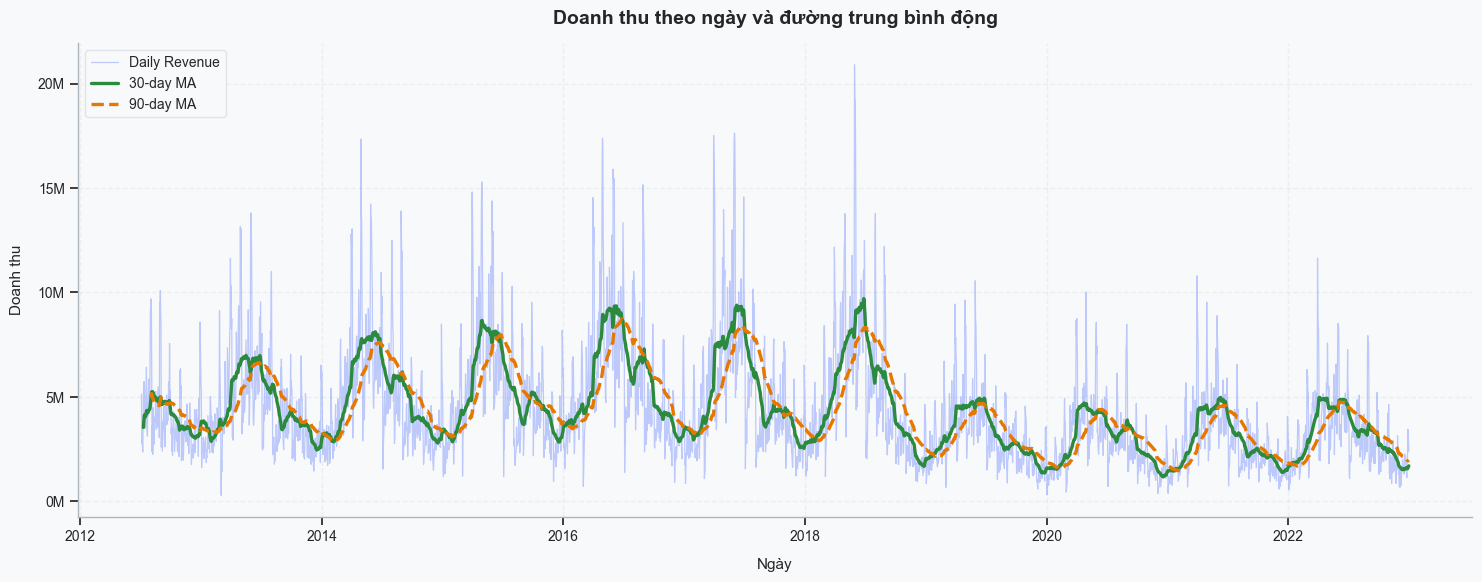

In [18]:
fig, ax = plt.subplots(figsize=(15, 6))
sns.lineplot(
    data=sales,
    x="Date",
    y="Revenue",
    ax=ax,
    color=LINE_DAILY,
    linewidth=0.9,
    alpha=0.45,
    label="Daily Revenue",
)
sns.lineplot(
    data=sales,
    x="Date",
    y="rev_30d_ma",
    ax=ax,
    color=LINE_MA30,
    linewidth=2.4,
    label="30-day MA",
)
sns.lineplot(
    data=sales,
    x="Date",
    y="rev_90d_ma",
    ax=ax,
    color=LINE_MA90,
    linewidth=2.4,
    linestyle="--",
    label="90-day MA",
)
ax.set_title("Doanh thu theo ngày và đường trung bình động")
ax.set_xlabel("Ngày")
ax.set_ylabel("Doanh thu")
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x/1e9:.1f}B" if abs(x) >= 1e9 else f"{x/1e6:.0f}M")
)
ax.legend(loc="upper left", frameon=True)
ax.grid(True, axis="y", linestyle="--", alpha=0.45)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

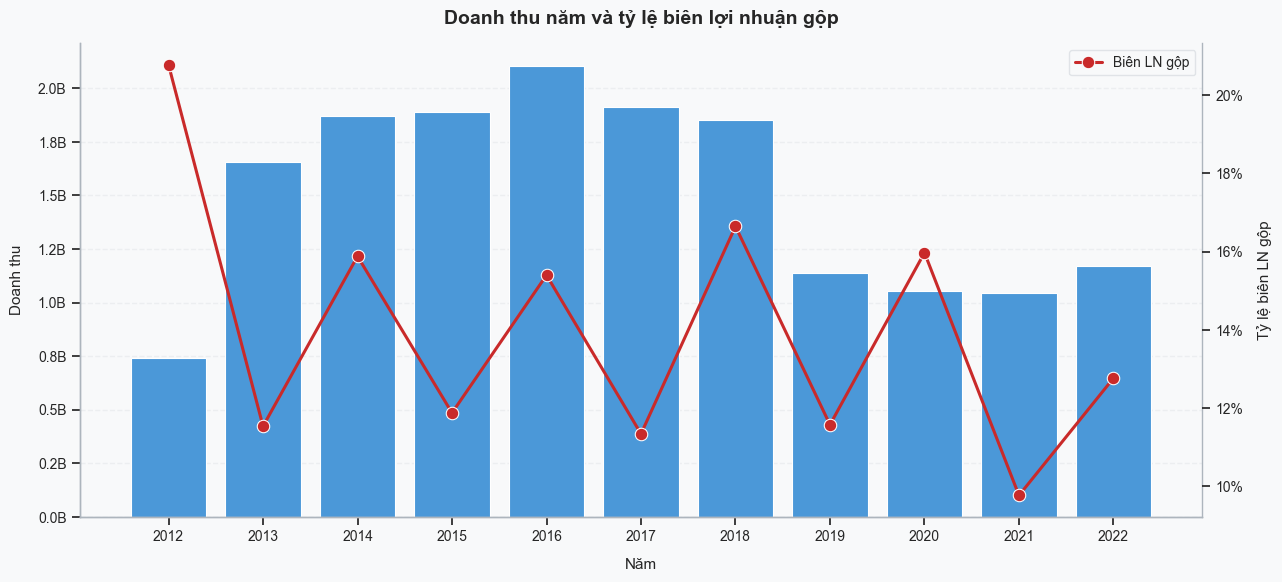

,year,Revenue,COGS,gross_margin,gross_margin_pct,yoy_growth
0,2012,"741,497,748.02","587,461,923.81","154,035,824.21",0.21,NaN
1,2013,"1,657,169,417.27","1,465,980,103.20","191,189,314.07",0.12,1.23
2,2014,"1,871,845,882.80","1,574,607,456.89","297,238,425.91",0.16,0.13
3,2015,"1,889,933,826.92","1,665,441,817.42","224,492,009.50",0.12,0.01
4,2016,"2,104,640,677.54","1,780,559,392.69","324,081,284.85",0.15,0.11
5,2017,"1,911,164,325.28","1,694,385,793.54","216,778,531.74",0.11,-0.09
6,2018,"1,850,122,456.08","1,542,175,766.14","307,946,689.94",0.17,-0.03
7,2019,"1,136,801,441.51","1,005,202,883.72","131,598,557.79",0.12,-0.39
8,2020,"1,054,512,158.79","886,085,097.63","168,427,061.16",0.16,-0.07
9,2021,"1,043,039,819.63","941,130,120.16","101,909,699.47",0.10,-0.01


In [19]:
annual = sales.groupby("year", as_index=False).agg(
    Revenue=("Revenue", "sum"),
    COGS=("COGS", "sum"),
    gross_margin=("gross_margin", "sum")
)
annual["gross_margin_pct"] = annual["gross_margin"] / annual["Revenue"]
annual["yoy_growth"] = annual["Revenue"].pct_change()

fig, ax1 = plt.subplots(figsize=(13, 6))
sns.barplot(data=annual, x="year", y="Revenue", ax=ax1, color=TWIN_FILL, edgecolor="white", linewidth=0.8)
ax1.set_title("Doanh thu năm và tỷ lệ biên lợi nhuận gộp")
ax1.set_xlabel("Năm")
ax1.set_ylabel("Doanh thu")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1e9:.1f}B"))

ax2 = ax1.twinx()
sns.lineplot(
    data=annual,
    x=np.arange(len(annual)),
    y="gross_margin_pct",
    marker="o",
    markersize=9,
    ax=ax2,
    color=TWIN_ACCENT,
    linewidth=2.2,
    label="Biên LN gộp",
)
ax2.set_ylabel("Tỷ lệ biên LN gộp")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax2.grid(False)
ax2.set_xticks(np.arange(len(annual)))
ax2.set_xticklabels(annual["year"].astype(int))
handles, labels = ax2.get_legend_handles_labels()
ax1.legend(handles, labels, loc="upper right", frameon=True)
ax2.get_legend().remove()
ax1.grid(True, axis="y", linestyle="--", alpha=0.45)
sns.despine(ax=ax1, right=False)
sns.despine(ax=ax2, left=False)
plt.tight_layout()
plt.show()

display(annual)

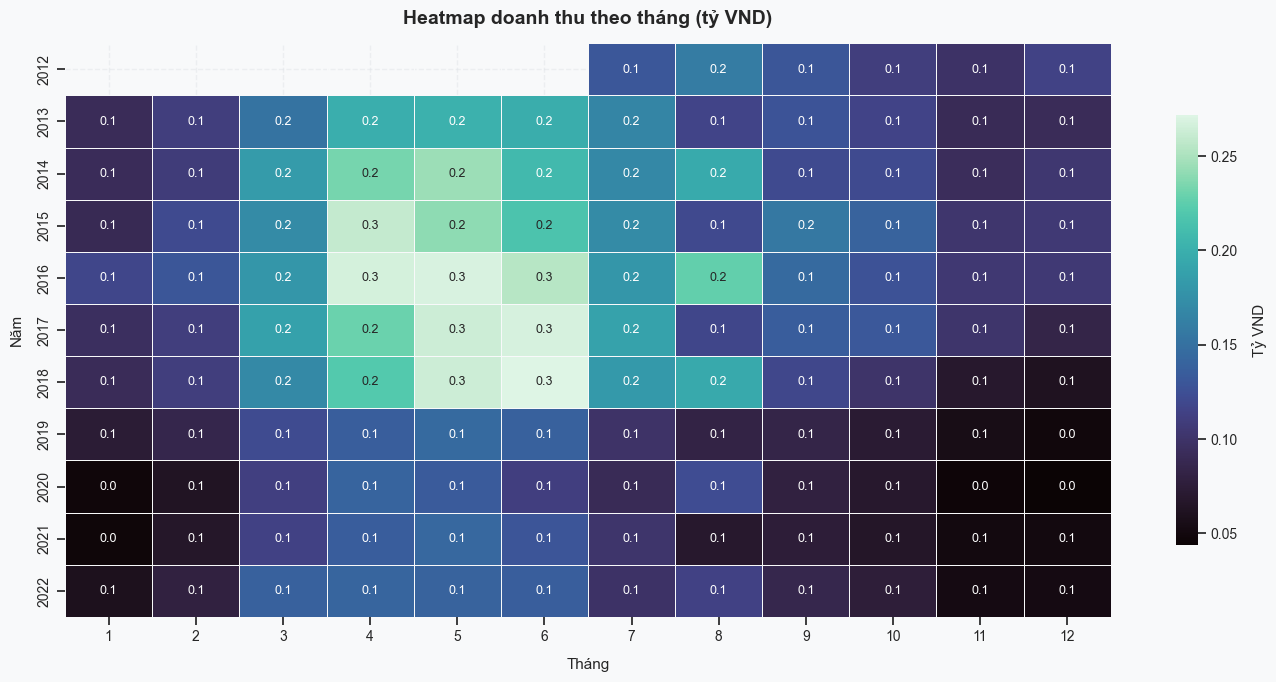

In [20]:
monthly = sales.groupby(["year", "month"], as_index=False).agg(Revenue=("Revenue", "sum"))
monthly_pivot = monthly.pivot(index="year", columns="month", values="Revenue")

plt.figure(figsize=(14, 7))
ax = sns.heatmap(
    monthly_pivot / 1e9,
    cmap=sns.color_palette("mako", as_cmap=True),
    annot=True,
    fmt=".1f",
    linewidths=0.6,
    linecolor="#f8f9fa",
    cbar_kws={"label": "Tỷ VND", "shrink": 0.75},
    annot_kws={"size": 9},
)
ax.set_title("Heatmap doanh thu theo tháng (tỷ VND)", pad=14)
ax.set_xlabel("Tháng")
ax.set_ylabel("Năm")
plt.tight_layout()
plt.show()

### So what?

- Doanh thu có **xu hướng dài hạn + nhiễu theo ngày + mùa vụ theo tháng/năm**. Vì vậy, các mô hình dự báo ở Phần 3 nên có biến calendar, Fourier seasonality, lag 7/30/365 ngày và rolling mean.
- Các tháng/năm có mức doanh thu cao bất thường nên được xem như **đợt campaign hoặc mùa cao điểm**, không nên chỉ dùng trung bình quá khứ.
- Về kinh doanh: kế hoạch tồn kho và logistics nên lập theo **seasonal demand calendar**, không chia đều theo tháng.

---

# Insight 2 — Cơ cấu sản phẩm: Streetwear kéo doanh thu, nhưng category có biên tốt mới quyết định lợi nhuận

**Cấp độ:** Descriptive → Diagnostic  
**Câu hỏi:** Category nào tạo doanh thu, category nào tạo biên lợi nhuận?

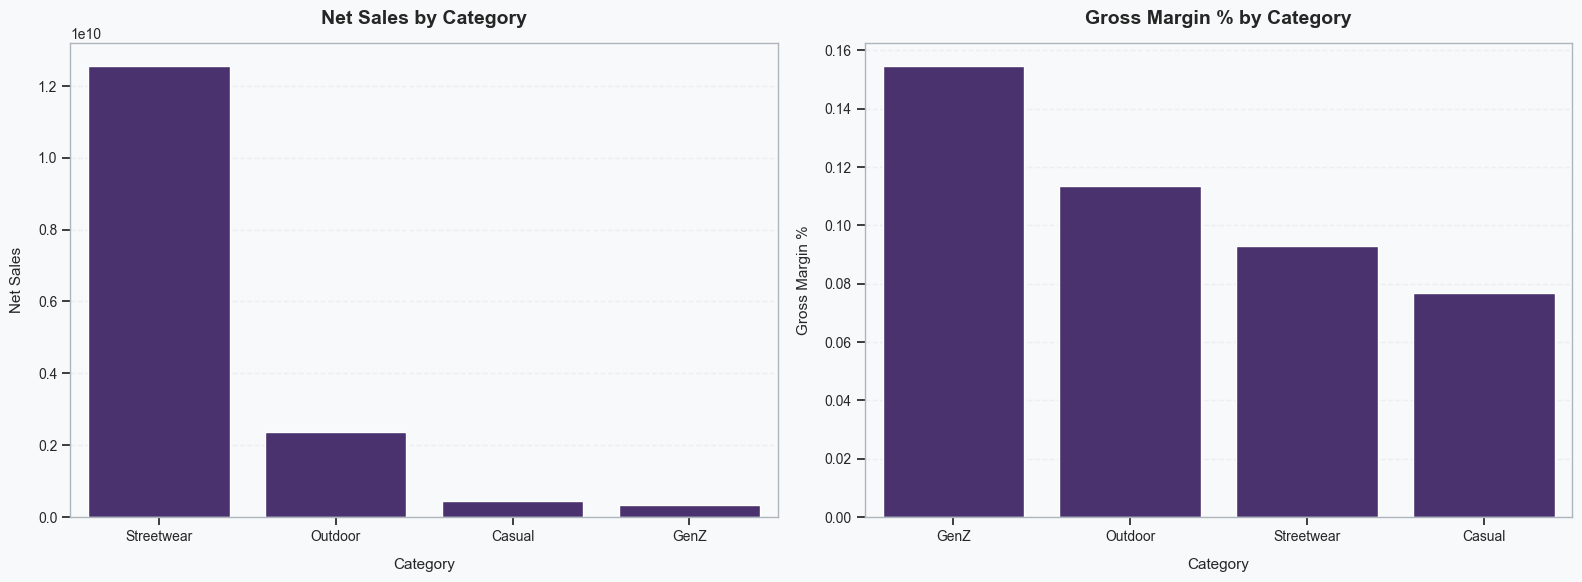

,category,net_sales,quantity,orders,discount,gross_profit,gross_margin_pct,discount_rate
3,Streetwear,"12,558,477,099.17",1768826,389543,"572,869,253.45","1,165,807,511.55",0.09,0.04
2,Outdoor,"2,353,396,796.86",1170000,200454,"141,485,957.34","267,034,092.02",0.11,0.06
0,Casual,"440,285,193.75",107469,23600,"20,363,189.60","33,740,765.23",0.08,0.04
1,GenZ,"328,710,175.65",166848,37054,"14,888,919.71","50,836,377.50",0.15,0.04


In [21]:
category_perf = transactions.groupby("category", as_index=False).agg(
    net_sales=("net_sales", "sum"),
    quantity=("quantity", "sum"),
    orders=("order_id", "nunique"),
    discount=("discount_amount", "sum"),
    gross_profit=("gross_profit", "sum")
)
category_perf["gross_margin_pct"] = category_perf["gross_profit"] / category_perf["net_sales"]
category_perf["discount_rate"] = category_perf["discount"] / (category_perf["net_sales"] + category_perf["discount"])
category_perf = category_perf.sort_values("net_sales", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=category_perf, x="category", y="net_sales", ax=axes[0])
axes[0].set_title("Net Sales by Category")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Net Sales")

sns.barplot(data=category_perf.sort_values("gross_margin_pct", ascending=False), x="category", y="gross_margin_pct", ax=axes[1])
axes[1].set_title("Gross Margin % by Category")
axes[1].set_xlabel("Category")
axes[1].set_ylabel("Gross Margin %")

plt.tight_layout()
plt.show()

display(category_perf)

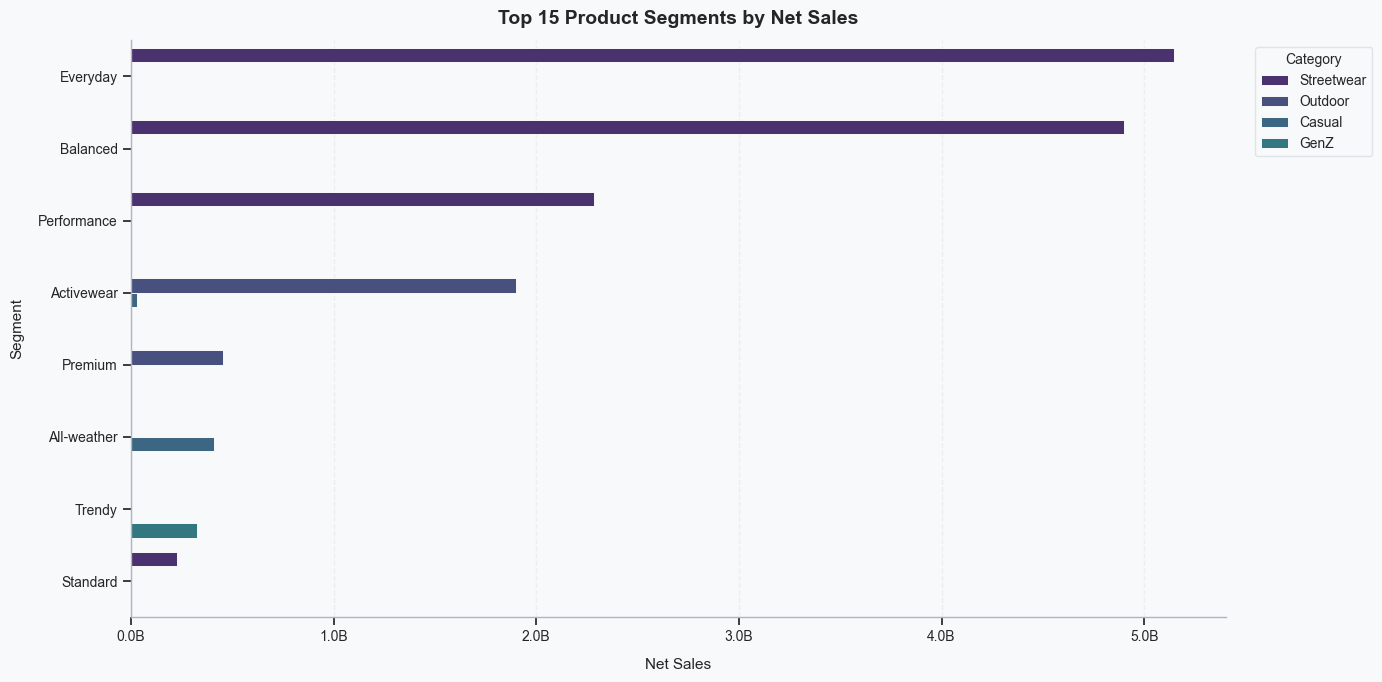

,category,segment,net_sales,gross_profit,quantity,gross_margin_pct
6,Streetwear,Everyday,"5,147,454,916.61","532,174,759.32",819449,0.10
5,Streetwear,Balanced,"4,900,317,965.89","431,236,060.66",464217,0.09
7,Streetwear,Performance,"2,285,029,332.18","173,693,836.66",435685,0.08
3,Outdoor,Activewear,"1,899,184,896.32","240,447,865.89",1030535,0.13
4,Outdoor,Premium,"454,211,900.54","26,586,226.14",139465,0.06
1,Casual,All-weather,"408,765,115.41","27,849,081.93",101147,0.07
2,GenZ,Trendy,"328,710,175.65","50,836,377.50",166848,0.15
8,Streetwear,Standard,"225,674,884.49","28,702,854.91",49475,0.13
0,Casual,Activewear,"31,520,078.34","5,891,683.30",6322,0.19


In [22]:
segment_perf = transactions.groupby(["category", "segment"], as_index=False).agg(
    net_sales=("net_sales", "sum"),
    gross_profit=("gross_profit", "sum"),
    quantity=("quantity", "sum")
)
segment_perf["gross_margin_pct"] = segment_perf["gross_profit"] / segment_perf["net_sales"]
top_segments = segment_perf.sort_values("net_sales", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(14, 7))
sns.barplot(
    data=top_segments,
    y="segment",
    x="net_sales",
    hue="category",
    ax=ax,
    edgecolor="white",
    linewidth=0.65,
)
ax.set_title("Top 15 Product Segments by Net Sales", pad=12)
ax.set_xlabel("Net Sales")
ax.set_ylabel("Segment")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1e9:.1f}B"))
ax.grid(True, axis="x", linestyle="--", alpha=0.45)
ax.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

display(top_segments)

### So what?

- Category có doanh thu lớn không nhất thiết là category có **gross margin %** tốt nhất.
- Khi lập kế hoạch tăng trưởng, doanh nghiệp nên tách hai mục tiêu:
  - **Revenue driver:** category/segment kéo volume và traffic.
  - **Profit driver:** category/segment có margin cao, phù hợp để upsell/bundle.
- Khuyến nghị: không phân bổ ngân sách marketing chỉ theo doanh thu. Nên dùng chỉ số **incremental gross profit** hoặc **Revenue × gross margin %**.

---

# Insight 3 — Khuyến mãi tạo doanh thu nhưng đang bào mòn biên lợi nhuận

**Cấp độ:** Diagnostic → Prescriptive  
**Câu hỏi:** Promotion có thực sự tốt nếu nhìn ở cấp dòng sản phẩm?

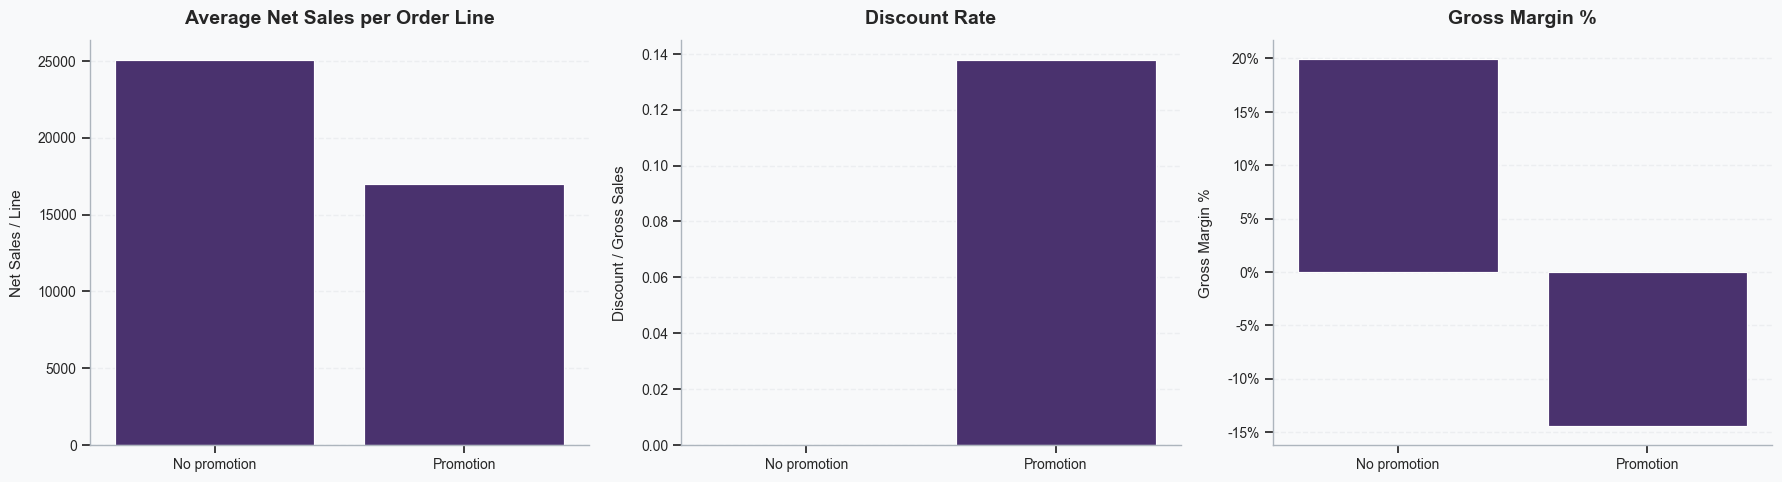

,has_promo,lines,gross_sales,net_sales,discount,quantity,gross_profit,discount_rate,gross_margin_pct,avg_net_sales_per_line,promo_label
0,False,438353,"10,995,039,052.90","10,995,039,052.90",0.00,1971104,"2,195,015,385.58",0.00,0.20,"25,082.61",No promotion
1,True,276316,"5,435,437,532.63","4,685,830,212.53","749,607,320.10",1242039,"-677,596,639.27",0.14,-0.14,"16,958.23",Promotion


In [23]:
promo_perf = transactions.groupby("has_promo", as_index=False).agg(
    lines=("order_id", "count"),
    gross_sales=("gross_sales", "sum"),
    net_sales=("net_sales", "sum"),
    discount=("discount_amount", "sum"),
    quantity=("quantity", "sum"),
    gross_profit=("gross_profit", "sum")
)
promo_perf["discount_rate"] = promo_perf["discount"] / promo_perf["gross_sales"]
promo_perf["gross_margin_pct"] = promo_perf["gross_profit"] / promo_perf["net_sales"]
promo_perf["avg_net_sales_per_line"] = promo_perf["net_sales"] / promo_perf["lines"]
promo_perf["promo_label"] = promo_perf["has_promo"].map({False: "No promotion", True: "Promotion"})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (y, title, ylab) in enumerate(
    [
        ("avg_net_sales_per_line", "Average Net Sales per Order Line", "Net Sales / Line"),
        ("discount_rate", "Discount Rate", "Discount / Gross Sales"),
        ("gross_margin_pct", "Gross Margin %", "Gross Margin %"),
    ]
):
    sns.barplot(
        data=promo_perf,
        x="promo_label",
        y=y,
        ax=axes[i],
        edgecolor="white",
        linewidth=0.85,
    )
    axes[i].set_title(title, pad=12)
    axes[i].set_xlabel("")
    axes[i].set_ylabel(ylab)
    if y == "gross_margin_pct":
        axes[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
    axes[i].grid(True, axis="y", linestyle="--", alpha=0.45)
    sns.despine(ax=axes[i])

plt.tight_layout()
plt.show()

display(promo_perf)

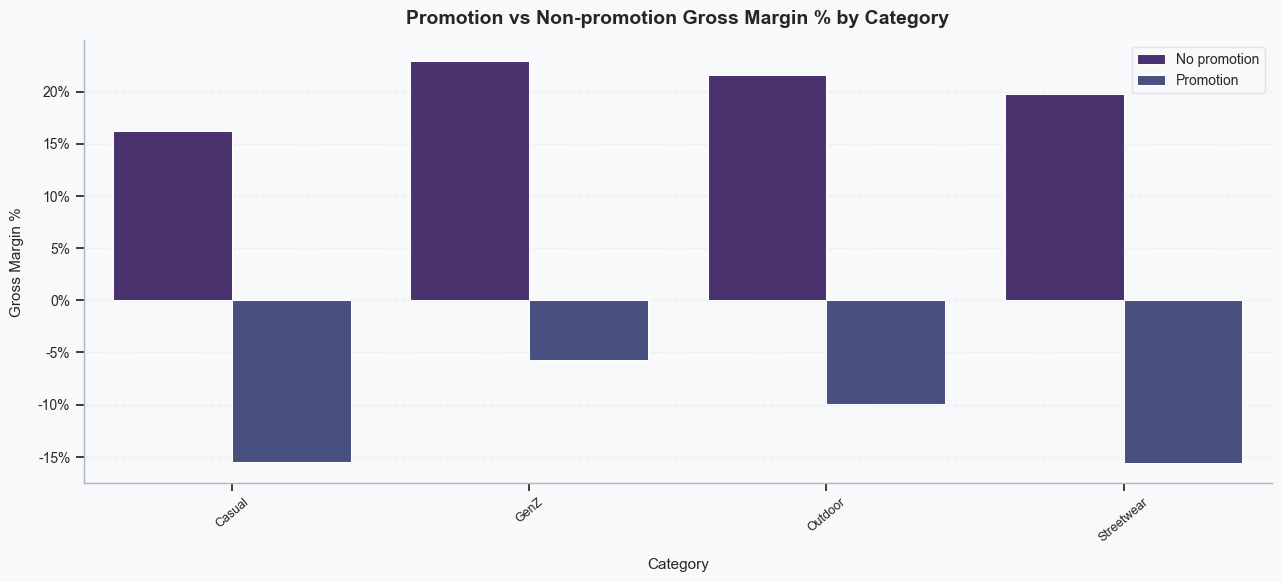

,category,has_promo,net_sales,gross_profit,discount,gross_sales,lines,gross_margin_pct,discount_rate,promo_label
0,Casual,False,"321,956,863.25","52,094,973.76",0.00,"321,956,863.25",15916,0.16,0.00,No promotion
1,Casual,True,"118,328,330.50","-18,354,208.52","20,363,189.60","138,691,520.10",8075,-0.16,0.15,Promotion
2,GenZ,False,"242,810,370.19","55,774,033.81",0.00,"242,810,370.19",24927,0.23,0.00,No promotion
3,GenZ,True,"85,899,805.46","-4,937,656.31","14,888,919.71","100,788,725.17",12232,-0.06,0.15,Promotion
4,Outdoor,False,"1,589,211,897.09","342,683,440.57",0.00,"1,589,211,897.09",151645,0.22,0.00,No promotion
5,Outdoor,True,"764,184,899.77","-75,649,348.55","141,485,957.34","905,670,857.11",108341,-0.10,0.16,Promotion
6,Streetwear,False,"8,841,059,922.37","1,744,462,937.44",0.00,"8,841,059,922.37",245865,0.20,0.00,No promotion
7,Streetwear,True,"3,717,417,176.80","-578,655,425.89","572,869,253.45","4,290,286,430.25",147668,-0.16,0.13,Promotion


In [24]:
promo_category = transactions.groupby(["category", "has_promo"], as_index=False).agg(
    net_sales=("net_sales", "sum"),
    gross_profit=("gross_profit", "sum"),
    discount=("discount_amount", "sum"),
    gross_sales=("gross_sales", "sum"),
    lines=("order_id", "count")
)
promo_category["gross_margin_pct"] = promo_category["gross_profit"] / promo_category["net_sales"]
promo_category["discount_rate"] = promo_category["discount"] / promo_category["gross_sales"]
promo_category["promo_label"] = promo_category["has_promo"].map({False: "No promotion", True: "Promotion"})

fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(
    data=promo_category,
    x="category",
    y="gross_margin_pct",
    hue="promo_label",
    ax=ax,
    edgecolor="white",
    linewidth=0.75,
)
ax.set_title("Promotion vs Non-promotion Gross Margin % by Category", pad=12)
ax.set_xlabel("Category")
ax.set_ylabel("Gross Margin %")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.tick_params(axis="x", rotation=40, labelsize=9)
ax.grid(True, axis="y", linestyle="--", alpha=0.45)
ax.legend(title="", frameon=True)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

display(promo_category.sort_values(["category", "has_promo"]))

### So what?

- Nếu dòng có promotion có gross margin thấp hoặc âm, promotion không nên được đánh giá bằng revenue đơn thuần.
- Promotion nên được chia thành 3 loại:
  1. **Traffic acquisition:** chấp nhận margin thấp nhưng giới hạn ngân sách.
  2. **Inventory clearance:** dùng cho SKU tồn kho cao/overstock.
  3. **Profit-preserving promotion:** bundle hoặc threshold promotion để giữ biên.
- Khuyến nghị cụ thể:
  - Đặt **minimum order value** theo category để tránh đơn khuyến mãi lỗ.
  - Ưu tiên promotion cho SKU có overstock hoặc sell-through thấp.
  - Báo cáo campaign nên theo **incremental gross profit**, không chỉ revenue uplift.

---

# Insight 4 — Vùng địa lý và kênh đặt hàng cho thấy nơi cần ưu tiên logistics và marketing

**Cấp độ:** Descriptive → Diagnostic → Prescriptive  
**Câu hỏi:** Vùng nào/kênh nào tạo doanh thu? Nên ưu tiên vận hành ở đâu?

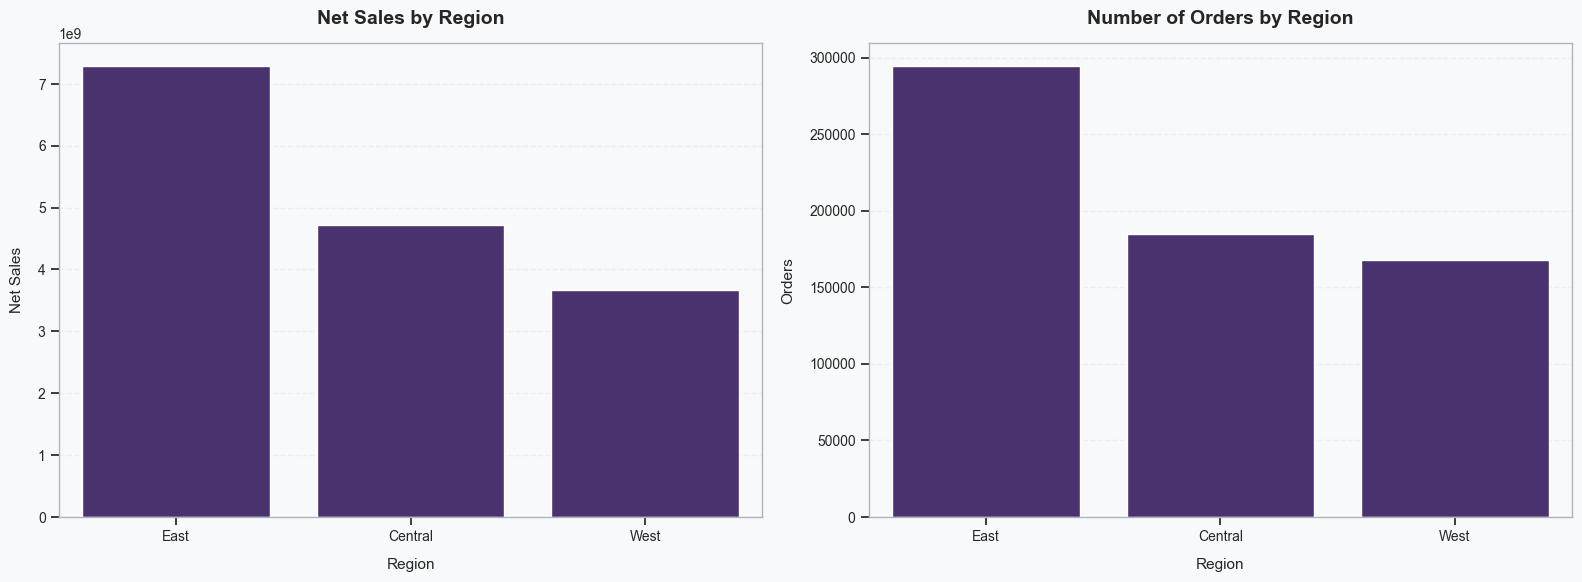

,region,net_sales,orders,quantity,gross_profit,gross_margin_pct
1,East,"7,291,150,819.12",294612,1443711,"695,648,303.61",0.10
0,Central,"4,719,491,267.84",184691,906968,"443,060,931.07",0.09
2,West,"3,670,227,178.47",167642,862464,"378,709,511.62",0.10


In [25]:
region_perf = transactions.groupby("region", as_index=False).agg(
    net_sales=("net_sales", "sum"),
    orders=("order_id", "nunique"),
    quantity=("quantity", "sum"),
    gross_profit=("gross_profit", "sum")
)
region_perf["gross_margin_pct"] = region_perf["gross_profit"] / region_perf["net_sales"]
region_perf = region_perf.sort_values("net_sales", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=region_perf, x="region", y="net_sales", ax=axes[0])
axes[0].set_title("Net Sales by Region")
axes[0].set_xlabel("Region")
axes[0].set_ylabel("Net Sales")

sns.barplot(data=region_perf.sort_values("orders", ascending=False), x="region", y="orders", ax=axes[1])
axes[1].set_title("Number of Orders by Region")
axes[1].set_xlabel("Region")
axes[1].set_ylabel("Orders")

plt.tight_layout()
plt.show()

display(region_perf)

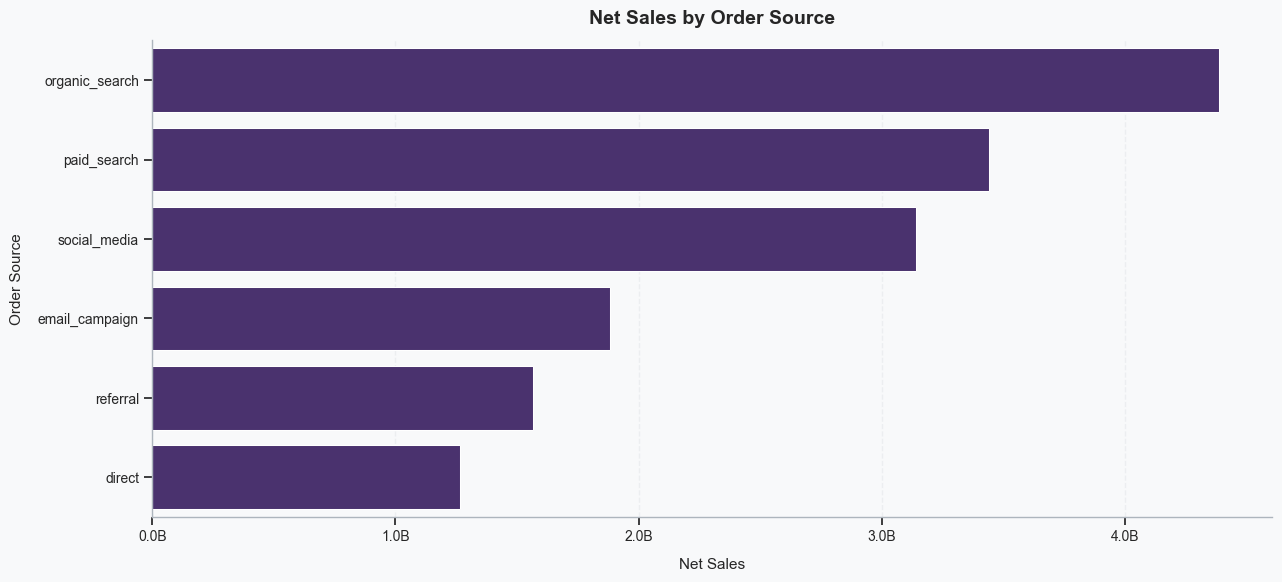

,order_source,net_sales,orders,gross_profit,gross_margin_pct
2,organic_search,"4,385,324,881.54",181495,"424,912,479.69",0.10
3,paid_search,"3,441,964,418.44",141652,"331,945,034.68",0.10
5,social_media,"3,141,153,470.29",129710,"304,816,933.49",0.10
1,email_campaign,"1,882,479,280.82",77572,"184,312,903.88",0.10
4,referral,"1,565,897,314.00",64565,"148,981,208.02",0.10
0,direct,"1,264,049,900.34",51951,"122,450,186.54",0.10


In [26]:
source_perf = transactions.groupby("order_source", as_index=False).agg(
    net_sales=("net_sales", "sum"),
    orders=("order_id", "nunique"),
    gross_profit=("gross_profit", "sum")
)
source_perf["gross_margin_pct"] = source_perf["gross_profit"] / source_perf["net_sales"]
source_perf = source_perf.sort_values("net_sales", ascending=False)

fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(
    data=source_perf,
    y="order_source",
    x="net_sales",
    ax=ax,
    edgecolor="white",
    linewidth=0.75,
)
ax.set_title("Net Sales by Order Source", pad=12)
ax.set_xlabel("Net Sales")
ax.set_ylabel("Order Source")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1e9:.1f}B"))
ax.grid(True, axis="x", linestyle="--", alpha=0.45)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

display(source_perf)

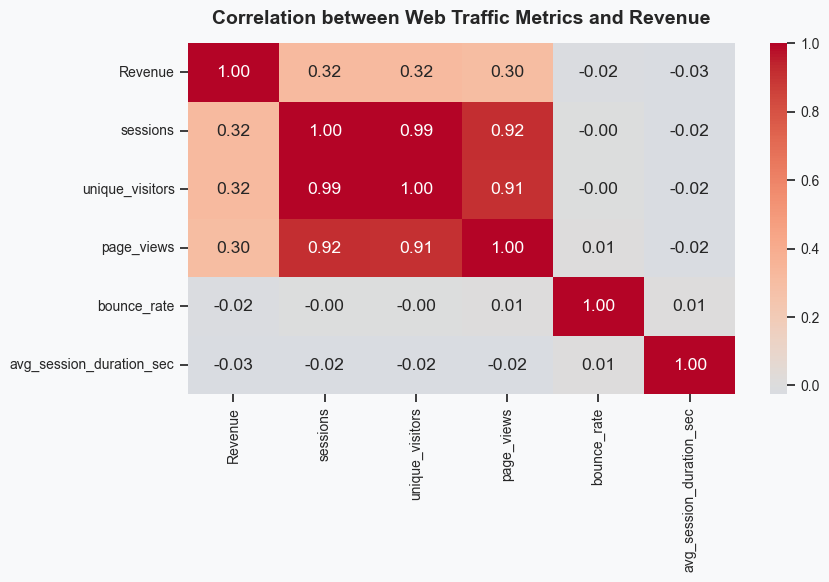

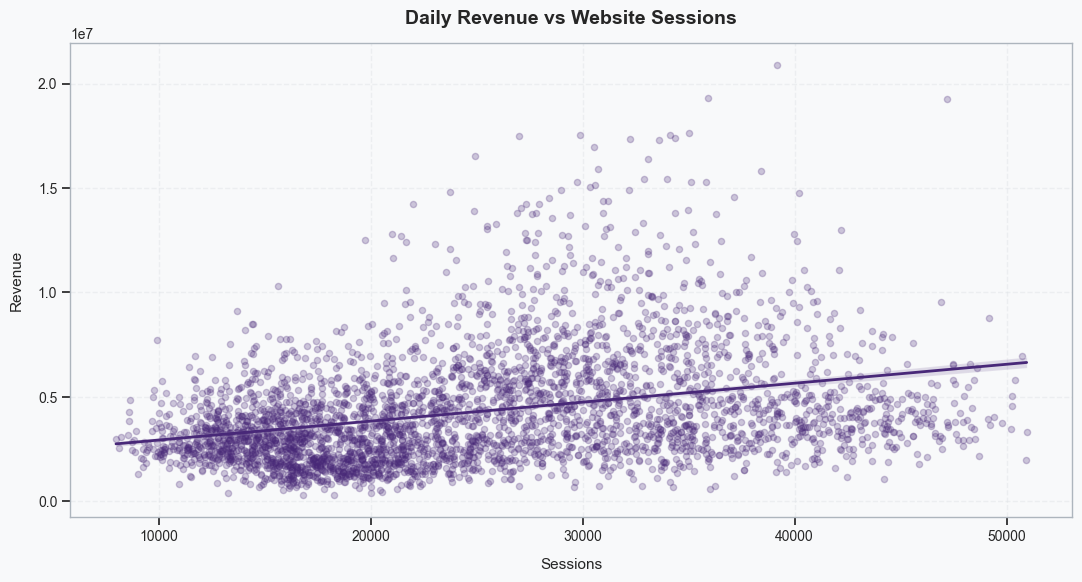

In [27]:
traffic_corr = sales_traffic[["Revenue", "sessions", "unique_visitors", "page_views", "bounce_rate", "avg_session_duration_sec"]].corr()

plt.figure(figsize=(9, 6))
sns.heatmap(traffic_corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation between Web Traffic Metrics and Revenue")
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 6))
sns.regplot(data=sales_traffic, x="sessions", y="Revenue", scatter_kws={"alpha": 0.25, "s": 20}, line_kws={"linewidth": 2})
plt.title("Daily Revenue vs Website Sessions")
plt.xlabel("Sessions")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

### So what?

- Vùng/kênh có doanh thu cao là nơi nên ưu tiên tồn kho, SLA giao hàng và campaign planning.
- Traffic có liên hệ dương với doanh thu, nhưng không đủ mạnh để giải thích toàn bộ doanh thu. Vì vậy, **conversion, basket size, category mix và promotion mix** mới là phần cần đào sâu.
- Khuyến nghị:
  - Kết hợp traffic forecast với revenue forecast để xác định ngày cần tăng năng lực logistics.
  - Ưu tiên campaign cho kênh có revenue cao nhưng vẫn theo dõi margin để tránh tăng trưởng không lợi nhuận.

---

# Insight 5 — Returns và giao hàng là điểm nghẽn trải nghiệm khách hàng

**Cấp độ:** Diagnostic → Prescriptive  
**Câu hỏi:** Trả hàng đến từ đâu và có liên quan đến vận hành giao hàng không?

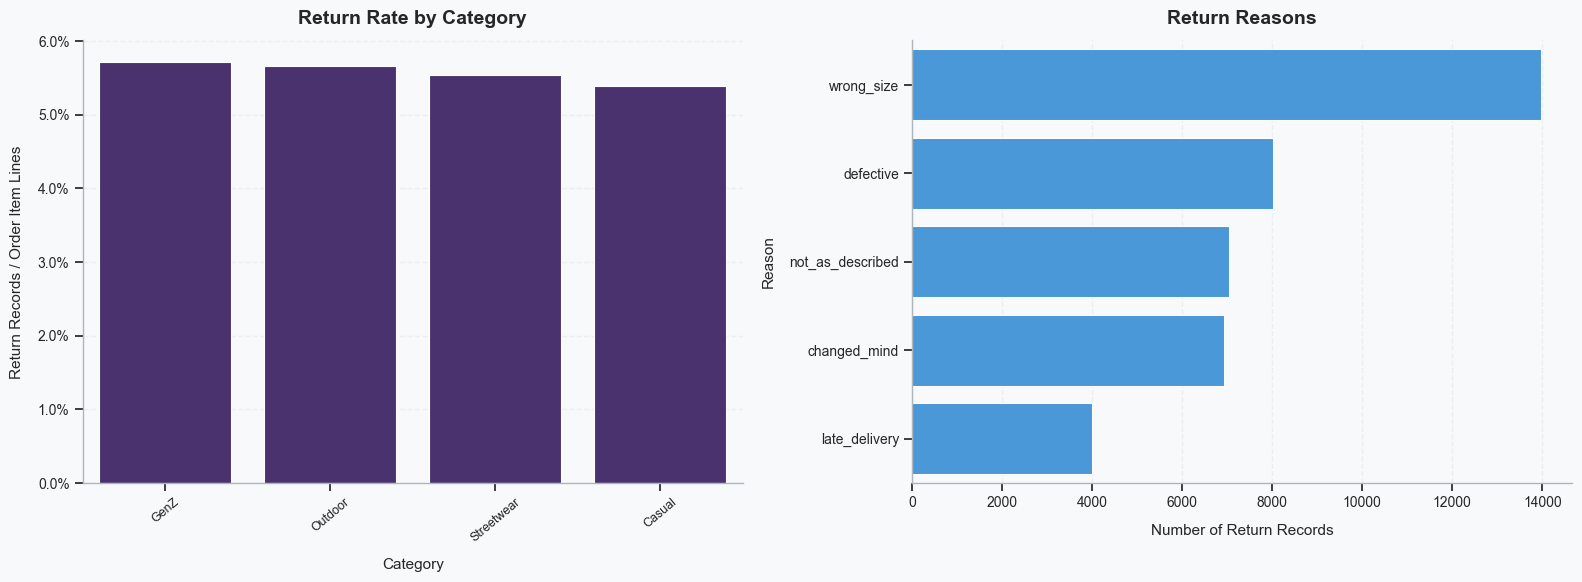

,category,return_records,return_qty,refund_amount,item_lines,return_rate_by_lines
1,GenZ,2126,5869,"11,145,648.17",37159,0.06
2,Outdoor,14720,40417,"78,717,514.88",259986,0.06
3,Streetwear,21799,59801,"406,708,249.13",393533,0.06
0,Casual,1294,3499,"14,027,094.37",23991,0.05


,return_reason,count
0,wrong_size,13967
1,defective,8020
2,not_as_described,7035
3,changed_mind,6931
4,late_delivery,3986


In [28]:
returns_prod = returns.merge(products[["product_id", "category", "segment", "size"]], on="product_id", how="left")
order_item_denominator = order_items.merge(products[["product_id", "category", "size"]], on="product_id", how="left")

return_category = returns_prod.groupby("category", as_index=False).agg(
    return_records=("return_id", "count"),
    return_qty=("return_quantity", "sum"),
    refund_amount=("refund_amount", "sum")
)
item_lines_category = order_item_denominator.groupby("category", as_index=False).agg(item_lines=("order_id", "count"))
return_category = return_category.merge(item_lines_category, on="category", how="left")
return_category["return_rate_by_lines"] = return_category["return_records"] / return_category["item_lines"]
return_category = return_category.sort_values("return_rate_by_lines", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=return_category,
    x="category",
    y="return_rate_by_lines",
    ax=axes[0],
    edgecolor="white",
    linewidth=0.8,
)
axes[0].set_title("Return Rate by Category", pad=12)
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Return Records / Order Item Lines")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.1%}"))
axes[0].tick_params(axis="x", rotation=40, labelsize=9)

reason_counts = returns["return_reason"].value_counts().reset_index()
reason_counts.columns = ["return_reason", "count"]
sns.barplot(
    data=reason_counts,
    y="return_reason",
    x="count",
    ax=axes[1],
    color=TWIN_FILL,
    edgecolor="white",
    linewidth=0.75,
)
axes[1].set_title("Return Reasons", pad=12)
axes[1].set_xlabel("Number of Return Records")
axes[1].set_ylabel("Reason")
axes[1].grid(True, axis="x", linestyle="--", alpha=0.45)

for ax in axes:
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

display(return_category)
display(reason_counts)

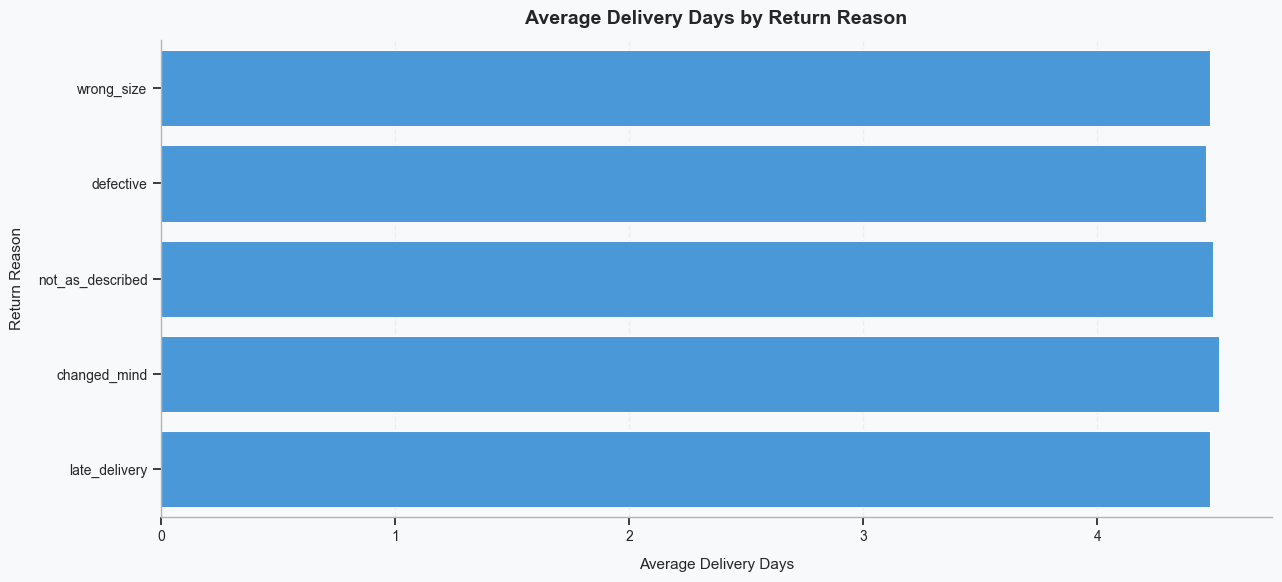

,return_reason,return_records,avg_delivery_days,median_delivery_days,avg_refund
4,wrong_size,13967,4.48,4.00,"12,650.33"
1,defective,8020,4.46,4.00,"12,917.60"
3,not_as_described,7035,4.50,4.00,"12,886.03"
0,changed_mind,6931,4.52,5.00,"12,944.99"
2,late_delivery,3986,4.48,4.00,"12,528.15"


In [29]:
returns_ship = returns.merge(shipments[["order_id", "delivery_days"]], on="order_id", how="left")
reason_delivery = returns_ship.groupby("return_reason", as_index=False).agg(
    return_records=("return_id", "count"),
    avg_delivery_days=("delivery_days", "mean"),
    median_delivery_days=("delivery_days", "median"),
    avg_refund=("refund_amount", "mean")
).sort_values("return_records", ascending=False)

fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(
    data=reason_delivery,
    y="return_reason",
    x="avg_delivery_days",
    ax=ax,
    color=TWIN_FILL,
    edgecolor="white",
    linewidth=0.75,
)
ax.set_title("Average Delivery Days by Return Reason", pad=12)
ax.set_xlabel("Average Delivery Days")
ax.set_ylabel("Return Reason")
ax.grid(True, axis="x", linestyle="--", alpha=0.45)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

display(reason_delivery)

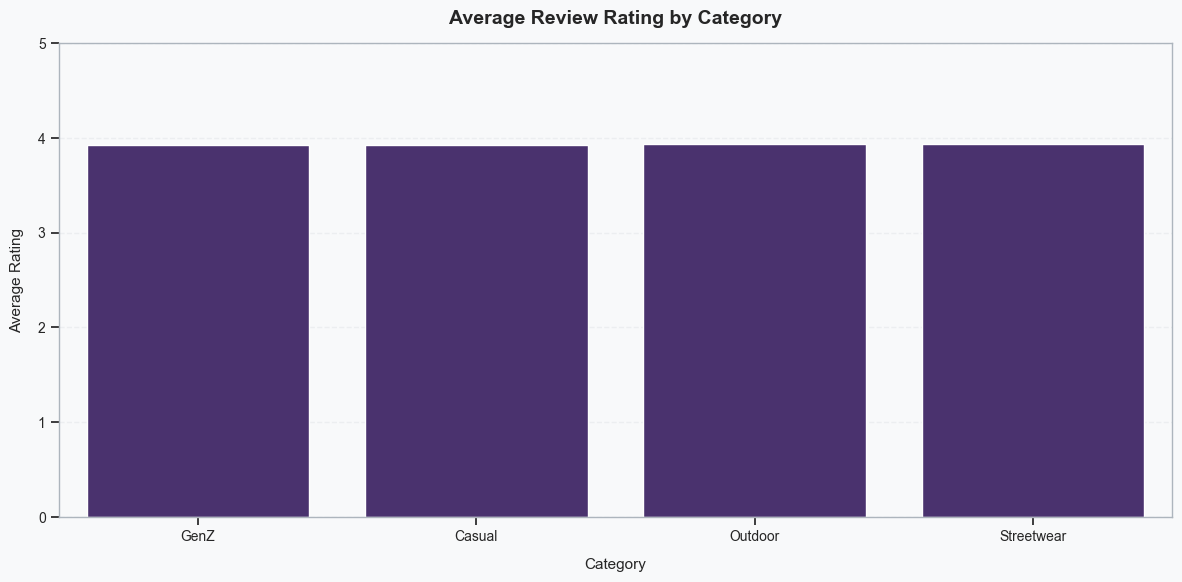

,category,avg_rating,reviews
1,GenZ,3.92,5792
0,Casual,3.92,3790
2,Outdoor,3.93,41265
3,Streetwear,3.94,62704


In [30]:
reviews_prod = reviews.merge(products[["product_id", "category"]], on="product_id", how="left")
rating_category = reviews_prod.groupby("category", as_index=False).agg(
    avg_rating=("rating", "mean"),
    reviews=("review_id", "count")
).sort_values("avg_rating")

plt.figure(figsize=(12, 6))
sns.barplot(data=rating_category, x="category", y="avg_rating")
plt.title("Average Review Rating by Category")
plt.xlabel("Category")
plt.ylabel("Average Rating")
plt.ylim(0, 5)
plt.tight_layout()
plt.show()

display(rating_category)

### So what?

- Return không chỉ là chi phí hoàn tiền; nó còn làm sai lệch dự báo nhu cầu nếu chỉ nhìn đơn hàng gross.
- Nên phân tách return theo:
  - **Product-fit issue:** sai size, mô tả không đúng, chất lượng.
  - **Operational issue:** giao trễ, hư hỏng.
  - **Customer preference:** đổi ý.
- Khuyến nghị:
  - Với reason liên quan size/chất lượng: cải thiện mô tả sản phẩm, size guide, review ảnh thật.
  - Với reason liên quan giao hàng: theo dõi carrier/SLA theo region.
  - Đưa return rate vào dashboard category để tránh đẩy mạnh sản phẩm có doanh thu cao nhưng hậu mãi kém.

---

# Insight 6 — Tồn kho: stockout cao làm mất doanh thu tiềm năng, overstock làm kẹt vốn

**Cấp độ:** Diagnostic → Predictive → Prescriptive  
**Câu hỏi:** Category nào có rủi ro thiếu hàng và nên được ưu tiên tái đặt hàng?

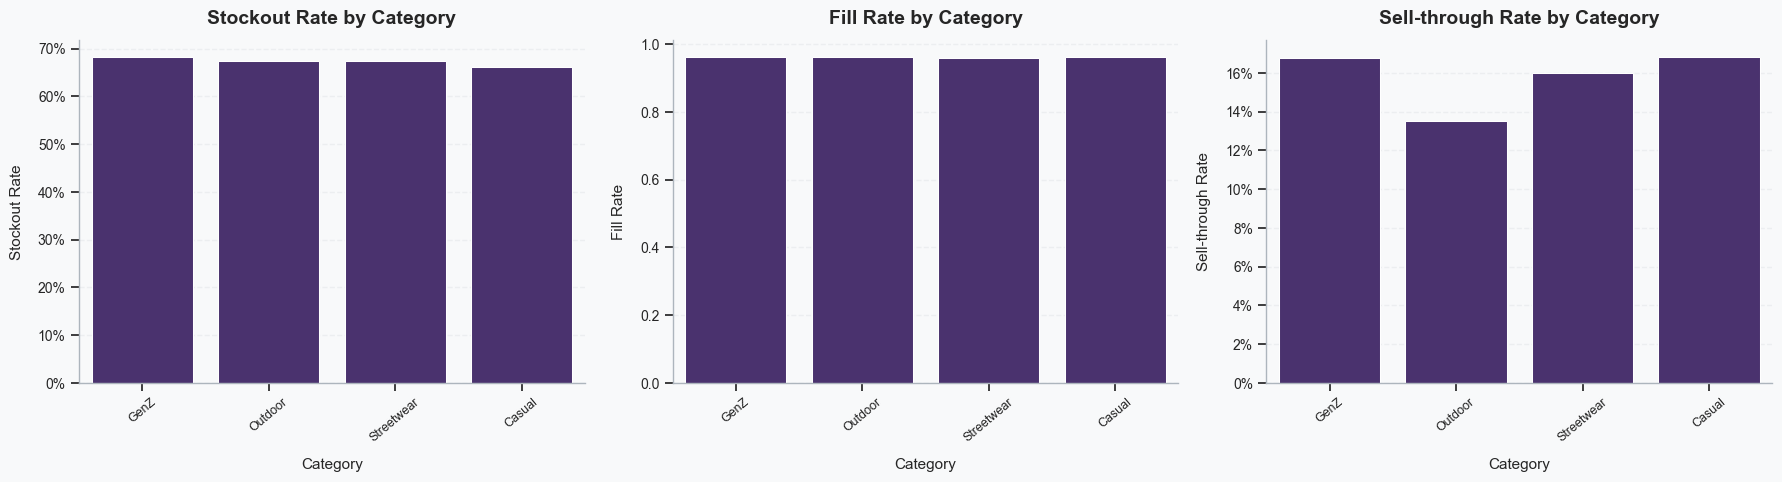

,category,stockout_rate,overstock_rate,reorder_rate,fill_rate,avg_stockout_days,units_sold,sell_through_rate
1,GenZ,0.68,0.72,0.00,0.96,1.15,48695,0.17
2,Outdoor,0.67,0.80,0.00,0.96,1.12,337510,0.14
3,Streetwear,0.67,0.75,0.00,0.96,1.19,511467,0.16
0,Casual,0.66,0.73,0.00,0.96,1.15,31202,0.17


In [31]:
inventory_category = inventory.groupby("category", as_index=False).agg(
    stockout_rate=("stockout_flag", "mean"),
    overstock_rate=("overstock_flag", "mean"),
    reorder_rate=("reorder_flag", "mean"),
    fill_rate=("fill_rate", "mean"),
    avg_stockout_days=("stockout_days", "mean"),
    units_sold=("units_sold", "sum"),
    sell_through_rate=("sell_through_rate", "mean")
).sort_values("stockout_rate", ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (y, title, ylab, pct) in enumerate(
    [
        ("stockout_rate", "Stockout Rate by Category", "Stockout Rate", True),
        ("fill_rate", "Fill Rate by Category", "Fill Rate", False),
        ("sell_through_rate", "Sell-through Rate by Category", "Sell-through Rate", True),
    ]
):
    sns.barplot(
        data=inventory_category,
        x="category",
        y=y,
        ax=axes[i],
        edgecolor="white",
        linewidth=0.75,
    )
    axes[i].set_title(title, pad=12)
    axes[i].set_xlabel("Category")
    axes[i].set_ylabel(ylab)
    axes[i].tick_params(axis="x", rotation=40, labelsize=9)
    if pct:
        axes[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
    axes[i].grid(True, axis="y", linestyle="--", alpha=0.45)
    sns.despine(ax=axes[i])

plt.tight_layout()
plt.show()

display(inventory_category)

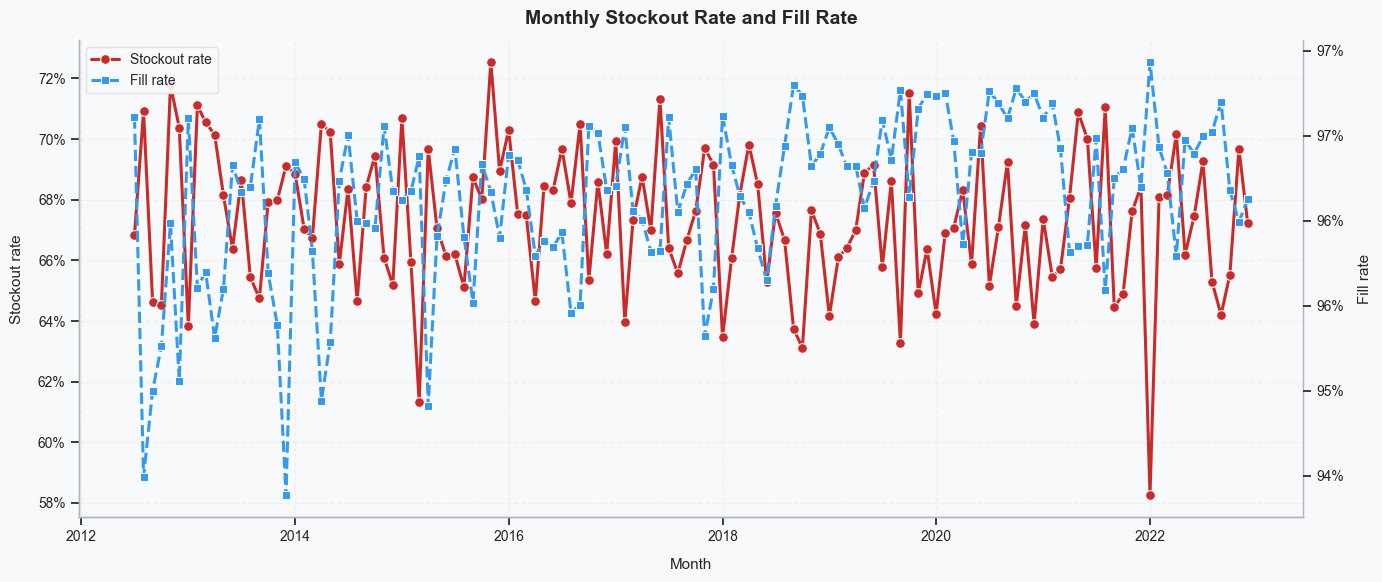

In [32]:
inventory_monthly = inventory.groupby(["year", "month"], as_index=False).agg(
    stockout_rate=("stockout_flag", "mean"),
    fill_rate=("fill_rate", "mean"),
    units_sold=("units_sold", "sum")
)
inventory_monthly["ym"] = pd.to_datetime(inventory_monthly["year"].astype(str) + "-" + inventory_monthly["month"].astype(str) + "-01")

fig, ax1 = plt.subplots(figsize=(14, 6))
sns.lineplot(
    data=inventory_monthly,
    x="ym",
    y="stockout_rate",
    marker="o",
    markersize=7,
    ax=ax1,
    color=TWIN_ACCENT,
    linewidth=2.2,
    label="Stockout rate",
)
ax1.set_title("Monthly Stockout Rate and Fill Rate", pad=12)
ax1.set_xlabel("Month")
ax1.set_ylabel("Stockout rate")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))

ax2 = ax1.twinx()
sns.lineplot(
    data=inventory_monthly,
    x="ym",
    y="fill_rate",
    marker="s",
    markersize=6,
    ax=ax2,
    color=TWIN_FILL,
    linewidth=2.2,
    linestyle="--",
    label="Fill rate",
)
ax2.set_ylabel("Fill rate")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax2.grid(False)

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
leg2 = ax2.get_legend()
if leg2 is not None:
    leg2.remove()
ax1.legend(h1 + h2, l1 + l2, loc="upper left", frameon=True)

ax1.grid(True, linestyle="--", alpha=0.4)
sns.despine(ax=ax1, right=False)
sns.despine(ax=ax2, left=False)
plt.tight_layout()
plt.show()

### So what?

- Nếu stockout rate cao, doanh thu quan sát được có thể **thấp hơn nhu cầu thực** vì khách không mua được hàng.
- Đối với forecasting, inventory features nên được dùng để giải thích những tháng demand bị chặn bởi thiếu hàng.
- Khuyến nghị:
  - Ưu tiên safety stock cho category/SKU có doanh thu lớn và stockout cao.
  - Với sản phẩm overstock, dùng promotion dạng clearance thay vì giảm giá đại trà.
  - Kết hợp forecast Revenue với reorder_flag để đưa ra kế hoạch mua hàng trước mùa cao điểm.

---

# 7. Prescriptive dashboard — Hành động đề xuất

Bảng dưới đây tóm tắt insight thành quyết định kinh doanh có thể triển khai.

In [33]:
recommendations = pd.DataFrame([
    {
        "Finding": "Revenue có mùa vụ rõ ràng",
        "Business risk": "Lập tồn kho đều theo tháng gây thiếu hàng mùa cao điểm",
        "Action": "Dùng seasonal demand calendar và forecast theo ngày/tháng",
        "Metric to track": "Forecast error, stockout rate, fill rate"
    },
    {
        "Finding": "Streetwear kéo doanh thu lớn",
        "Business risk": "Tập trung revenue nhưng bỏ qua margin",
        "Action": "Tách ngân sách marketing theo revenue driver và profit driver",
        "Metric to track": "Net sales, gross margin %, incremental profit"
    },
    {
        "Finding": "Promotion có thể bào mòn margin",
        "Business risk": "Tăng GMV nhưng giảm lợi nhuận",
        "Action": "Đặt minimum order value, dùng bundle/threshold promo",
        "Metric to track": "Discount rate, gross margin %, profit per campaign"
    },
    {
        "Finding": "Traffic liên hệ dương với revenue",
        "Business risk": "Tăng traffic nhưng không tăng conversion",
        "Action": "Kết hợp traffic forecast với conversion/category mix",
        "Metric to track": "Sessions, conversion proxy, revenue/session"
    },
    {
        "Finding": "Return rate và reasons khác nhau theo nhóm",
        "Business risk": "Chi phí hoàn hàng và mất lòng tin khách hàng",
        "Action": "Cải thiện size guide, mô tả sản phẩm và SLA giao hàng",
        "Metric to track": "Return rate, refund amount, review rating"
    },
    {
        "Finding": "Stockout rate cao ở một số category",
        "Business risk": "Mất doanh thu tiềm năng do không đủ hàng",
        "Action": "Ưu tiên reorder và safety stock theo forecast",
        "Metric to track": "Stockout days, fill rate, reorder rate"
    }
])
display(recommendations)

,Finding,Business risk,Action,Metric to track
0,Revenue có mùa vụ rõ ràng,Lập tồn kho đều theo tháng gây thiếu hàng mùa ...,Dùng seasonal demand calendar và forecast theo...,"Forecast error, stockout rate, fill rate"
1,Streetwear kéo doanh thu lớn,Tập trung revenue nhưng bỏ qua margin,Tách ngân sách marketing theo revenue driver v...,"Net sales, gross margin %, incremental profit"
2,Promotion có thể bào mòn margin,Tăng GMV nhưng giảm lợi nhuận,"Đặt minimum order value, dùng bundle/threshold...","Discount rate, gross margin %, profit per camp..."
3,Traffic liên hệ dương với revenue,Tăng traffic nhưng không tăng conversion,Kết hợp traffic forecast với conversion/catego...,"Sessions, conversion proxy, revenue/session"
4,Return rate và reasons khác nhau theo nhóm,Chi phí hoàn hàng và mất lòng tin khách hàng,"Cải thiện size guide, mô tả sản phẩm và SLA gi...","Return rate, refund amount, review rating"
5,Stockout rate cao ở một số category,Mất doanh thu tiềm năng do không đủ hàng,Ưu tiên reorder và safety stock theo forecast,"Stockout days, fill rate, reorder rate"


## 8. Export bảng tổng hợp cho report

Các bảng này có thể dùng trực tiếp trong báo cáo 4 trang hoặc appendix.

In [35]:
OUTPUT_DIR = Path("eda_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

annual.to_csv(OUTPUT_DIR / "annual_revenue_margin.csv", index=False)
category_perf.to_csv(OUTPUT_DIR / "category_performance.csv", index=False)
promo_perf.to_csv(OUTPUT_DIR / "promotion_performance.csv", index=False)
region_perf.to_csv(OUTPUT_DIR / "region_performance.csv", index=False)
return_category.to_csv(OUTPUT_DIR / "return_category.csv", index=False)
inventory_category.to_csv(OUTPUT_DIR / "inventory_category.csv", index=False)
recommendations.to_csv(OUTPUT_DIR / "recommendations.csv", index=False)

print(f"Saved summary tables to: {OUTPUT_DIR.resolve()}")

Saved summary tables to: D:\Documents\GitHub\Datathon\eda_outputs


# Kết luận cho report

Phân tích EDA cho thấy doanh nghiệp không nên tối ưu doanh thu đơn thuần. Câu chuyện dữ liệu hợp lý hơn là:

> **Tăng trưởng doanh thu cần đi cùng kiểm soát biên lợi nhuận, giảm return và giảm stockout.**

Ba hướng hành động có tác động cao nhất:

1. **Forecast-driven inventory:** dùng dự báo theo mùa vụ để chuẩn bị tồn kho trước các tháng cao điểm.
2. **Profit-aware promotion:** chuyển từ giảm giá đại trà sang promotion có điều kiện, bundle hoặc clearance cho SKU tồn kho cao.
3. **Experience-led growth:** giảm return bằng size guide, mô tả sản phẩm tốt hơn và kiểm soát delivery SLA theo region.

Các insight này cũng liên kết trực tiếp với Phần 3: feature engineering cho mô hình forecasting nên bao gồm calendar seasonality, promotion, traffic, inventory và lag/rolling revenue.